***
<p style="font-size:26px;">
<font color=red> Machine Learning Algorithms For Prediction</font>
<p style="margin-left:10%; margin-right:10%;">by the <font color=teal> Oracle Cloud Infrastructure</font></p>

***

## Overview:
This notebook provides a few algorithms for regression and classification for regressing and classifying `StitLen`.


We demonstrate simple steps for training models and deploying it to production. **Two approaches** are demonstared:
1. Regression: available data up until the race are used for regressing `StintLen` when `stintNumber==1` (tells us when to stop)
2. Classification: available data up until the race, and normalized `stintLen` from past events are used. In this case we **bucketized** `StintLen` (5 buckets) and label of buckets are served as `class label` 

---

## Contents:

* <a href='#data'>Load data</a>
* <a href='#modeling'>Modeling</a>
    * <a href='#dataprep'>Data prep for modeling</a> 
    * <a href='#createtraintestsamples'>Create train/test samples</a>
    * <a href='#regressionforStintOne'>Regression based model for Stint One</a>
    * <a href='#multiclassmodeling'>Multiclass Modeling</a>
    * <a href='#create_pipeline'>Create pipeline model</a>
* <a href='#serialize'>Serialization and model deploymnet </a>
* <a href='#invoke_endpoint'>Invoke endpoint</a>
* <a href='#cleanup'>Clean up and delete deployed model</a>
---

### Load basic packages

In [4]:
path = '/home/datascience/fast-track-ml/notebooks'
data_path = '../../fast-track-ml//data/'

In [5]:
import os
os.chdir(path)
import pandas as pd
import logging
import json
import pickle
import requests
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
def load_table_to_dataframe(conn, table_name):
    """
    Carrega os dados de uma tabela do banco de dados em um DataFrame.

    Parâmetros:
        conn: Conexão ativa com o banco de dados.
        table_name: Nome da tabela a ser carregada.

    Retorno:
        DataFrame contendo os dados da tabela.
    """
    query = f"SELECT * FROM {table_name}"
    return pd.read_sql(query, conn)


<a id='data'></a>
# Load data 

1. Load data `final_data.csv`
2. Remove unreliable stint lengths
2. Bucketize the target variable (StintLen)

In [7]:
import oci
import base64
import oracledb

# =========================
# Vault helper
# =========================
def get_secret(secret_ocid):
    signer = oci.auth.signers.get_resource_principals_signer()
    client = oci.secrets.SecretsClient(
        config={},
        signer=signer,
        service_endpoint="https://secrets.vaults.us-chicago-1.oci.oraclecloud.com"
    )
    response = client.get_secret_bundle(secret_ocid)
    return base64.b64decode(
        response.data.secret_bundle_content.content
    ).decode("utf-8")

# =========================
# Secrets
# =========================
user = get_secret("ocid1.vaultsecret.oc1.us-chicago-1.amaaaaaafioir7iaev2fy7ajd5jrnglamplrxkcldpw3am6icxz5e2luusrq")
password = get_secret("ocid1.vaultsecret.oc1.us-chicago-1.amaaaaaafioir7iamn3k5ewqmtxurqpmrpzrq6tuyqb445fcl4lbrpr5gsqq")
wallet_password = get_secret("ocid1.vaultsecret.oc1.us-chicago-1.amaaaaaafioir7iamn3k5ewqmtxurqpmrpzrq6tuyqb445fcl4lbrpr5gsqq")

# =========================
# DSN hard coded (válido)
# =========================
DSN = """
(description=
    (retry_count=20)
    (retry_delay=3)
    (address=(protocol=tcps)(port=1522)(host=adb.sa-saopaulo-1.oraclecloud.com))
    (connect_data=
        (service_name=jy2otyfomimhaoc_dbtest_high.adb.oraclecloud.com)
    )
    (security=(ssl_server_dn_match=yes))
)
"""

# =========================
# Connection
# =========================
conn = oracledb.connect(
    user=user,
    password=password,
    dsn=DSN,
    config_dir="/home/datascience/fast-track-ml/wallet",
    wallet_location="/home/datascience/fast-track-ml/wallet",
    wallet_password=wallet_password
)

print("Connection successful")


Connection successful


In [8]:
import pandas as pd
import re

query = "SELECT * FROM ADMIN.FINAL_DATA"

with conn.cursor() as cur:
    cur.execute(query)
    df = pd.DataFrame(cur.fetchall(), columns=[col[0] for col in cur.description])

df = df.rename(columns={
    'EVENTNAME': 'EventName',
    'ROUNDNUMBER': 'RoundNumber',
    'EVENTYEAR': 'eventYear',
    'TEAM': 'Team',
    'COMPOUND': 'Compound',
    'DRIVER': 'Driver',
    'STINT': 'Stint',
    'BESTPRERACETIME': 'bestPreRaceTime',
    'BESTLAPTIMEISFROM': 'bestLapTimeIsFrom',
    'MEANAIRTEMP': 'meanAirTemp',
    'MEANTRACKTEMP': 'meanTrackTemp',
    'MEANHUMID': 'meanHumid',
    'RAINFALL': 'Rainfall',
    'GRIDPOSITION': 'GridPosition',
    'POSITION': 'Position',
    'RACESTINTSNUMS': 'raceStintsNums',
    'TYREAGE': 'TyreAge',
    'LAPNUMBERATBEGININGOFSTINT': 'lapNumberAtBeginingOfStint',
    'STINTLEN': 'StintLen',
    'CIRCUITLENGTH': 'CircuitLength',
    'DESIGNEDLAPS': 'designedLaps',
    'FUEL_SLOPE': 'fuel_slope',
    'FUEL_BIAS': 'fuel_bias',
    'DEG_SLOPE': 'deg_slope',
    'DEG_BIAS': 'deg_bias',
    'LAG_SLOPE_MEAN': 'lag_slope_mean',
    'LAG_BIAS_MEAN': 'lag_bias_mean'
})



In [9]:
#df = pd.read_csv(data_path+'final_data.csv')

## remove any StintLen lesser than 5 and greather than 35
## SintNumber==1
df = df[(df['StintLen']>5) & (df['StintLen']<=35) & (df['Stint']==1)] #& (df['Stint']==1)


# Remove unreliable stint lengths
## bucketize `target variable` and assign a label to each bucket
bins = np.array([5,10,15,20,25,30,35])
labels = np.arange(len(bins)-1)

df['classLabels'] = pd.cut(df.StintLen, 
                           bins=bins,
                           labels=labels)



print('-'*80)
print('Size of Data: ', df.shape,'\n', '-'*80,'\n')

df.describe()

--------------------------------------------------------------------------------
Size of Data:  (1245, 29) 
 -------------------------------------------------------------------------------- 



,COLNAME_COL1_MISSING,RoundNumber,eventYear,Stint,bestPreRaceTime,meanAirTemp,meanTrackTemp,meanHumid,Rainfall,GridPosition,...,lapNumberAtBeginingOfStint,StintLen,CircuitLength,designedLaps,fuel_slope,fuel_bias,deg_slope,deg_bias,lag_slope_mean,lag_bias_mean
count,1245.000000,1245.000000,1245.000000,1245.0,1241.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,...,1245.000000,1245.000000,1245.000000,1245.000000,1018.000000,1018.000000,1113.000000,1113.000000,499.000000,499.000000
mean,2241.415261,10.200000,2019.663454,1.0,84.281007,23.612955,36.689646,50.329263,0.042356,9.896386,...,1.200000,19.091566,5.155001,60.604016,-0.098180,93.190559,-0.052755,92.093566,-0.032743,91.117093
std,1380.173202,6.086277,1.304206,0.0,12.141957,5.214138,9.677136,15.415271,0.176297,5.714372,...,0.431106,7.697849,0.743502,8.460699,0.255791,12.707129,0.304137,12.756687,0.194557,11.987333
min,2.000000,1.000000,2018.000000,1.0,53.818000,9.257143,15.100000,5.952381,0.000000,1.000000,...,1.000000,6.000000,3.337000,44.000000,-2.228067,67.187503,-4.171178,58.775627,-2.263061,58.802745
25%,971.000000,5.000000,2019.000000,1.0,76.084000,20.611111,30.114815,38.914286,0.000000,5.000000,...,1.000000,12.000000,4.575000,53.000000,-0.105521,83.897841,-0.079620,82.841308,-0.067615,83.087812
50%,2173.000000,9.000000,2019.000000,1.0,83.084000,23.400000,36.482353,52.953846,0.000000,9.000000,...,1.000000,19.000000,5.380000,58.000000,-0.068861,94.392583,-0.028546,92.014357,-0.023174,90.917408
75%,3496.000000,16.000000,2021.000000,1.0,92.910000,27.195652,43.990909,59.933333,0.000000,15.000000,...,1.000000,25.000000,5.793000,70.000000,-0.045283,102.717894,0.023332,101.736214,0.017903,100.405132
max,4609.000000,22.000000,2022.000000,1.0,136.522000,36.933333,56.500000,93.861905,1.000000,20.000000,...,3.000000,35.000000,7.004000,87.000000,1.353067,135.657542,0.892500,143.581418,0.606236,132.102434


*** x  **************************************************************************************************** 



,meanAirTemp,meanTrackTemp,meanHumid,Rainfall,GridPosition,Position,fuel_slope,fuel_bias,deg_slope,deg_bias,lag_slope_mean,lag_bias_mean,StintLen
meanAirTemp,1.000000,0.663675,-0.444119,-0.192573,-0.015639,0.000876,0.151660,-0.104514,0.019347,-0.064652,0.074730,-0.126194,0.020574
meanTrackTemp,0.663675,1.000000,-0.529146,-0.182086,-0.036777,-0.008589,0.152073,-0.338276,0.047006,-0.317015,0.062375,-0.346785,0.058043
meanHumid,-0.444119,-0.529146,1.000000,0.119725,0.028535,0.014163,-0.102847,0.212273,-0.036764,0.200019,-0.128200,0.223400,0.018757
Rainfall,-0.192573,-0.182086,0.119725,1.000000,0.012009,-0.011033,-0.159165,-0.049903,-0.189013,-0.090784,-0.144328,-0.150311,0.000735
GridPosition,-0.015639,-0.036777,0.028535,0.012009,1.000000,0.651358,-0.013452,0.052167,-0.008222,0.068650,0.035764,0.032741,0.024411
Position,0.000876,-0.008589,0.014163,-0.011033,0.651358,1.000000,0.016559,0.010725,0.033642,0.012545,0.088144,0.014264,-0.067770
fuel_slope,0.151660,0.152073,-0.102847,-0.159165,-0.013452,0.016559,1.000000,-0.382954,0.433799,-0.166655,0.250195,-0.104601,-0.058777
fuel_bias,-0.104514,-0.338276,0.212273,-0.049903,0.052167,0.010725,-0.382954,1.000000,-0.219654,0.935187,-0.145478,0.928197,-0.226292
deg_slope,0.019347,0.047006,-0.036764,-0.189013,-0.008222,0.033642,0.433799,-0.219654,1.000000,-0.298760,0.799506,-0.155678,-0.083707
deg_bias,-0.064652,-0.317015,0.200019,-0.090784,0.068650,0.012545,-0.166655,0.935187,-0.298760,1.000000,-0.186812,0.982413,-0.245747


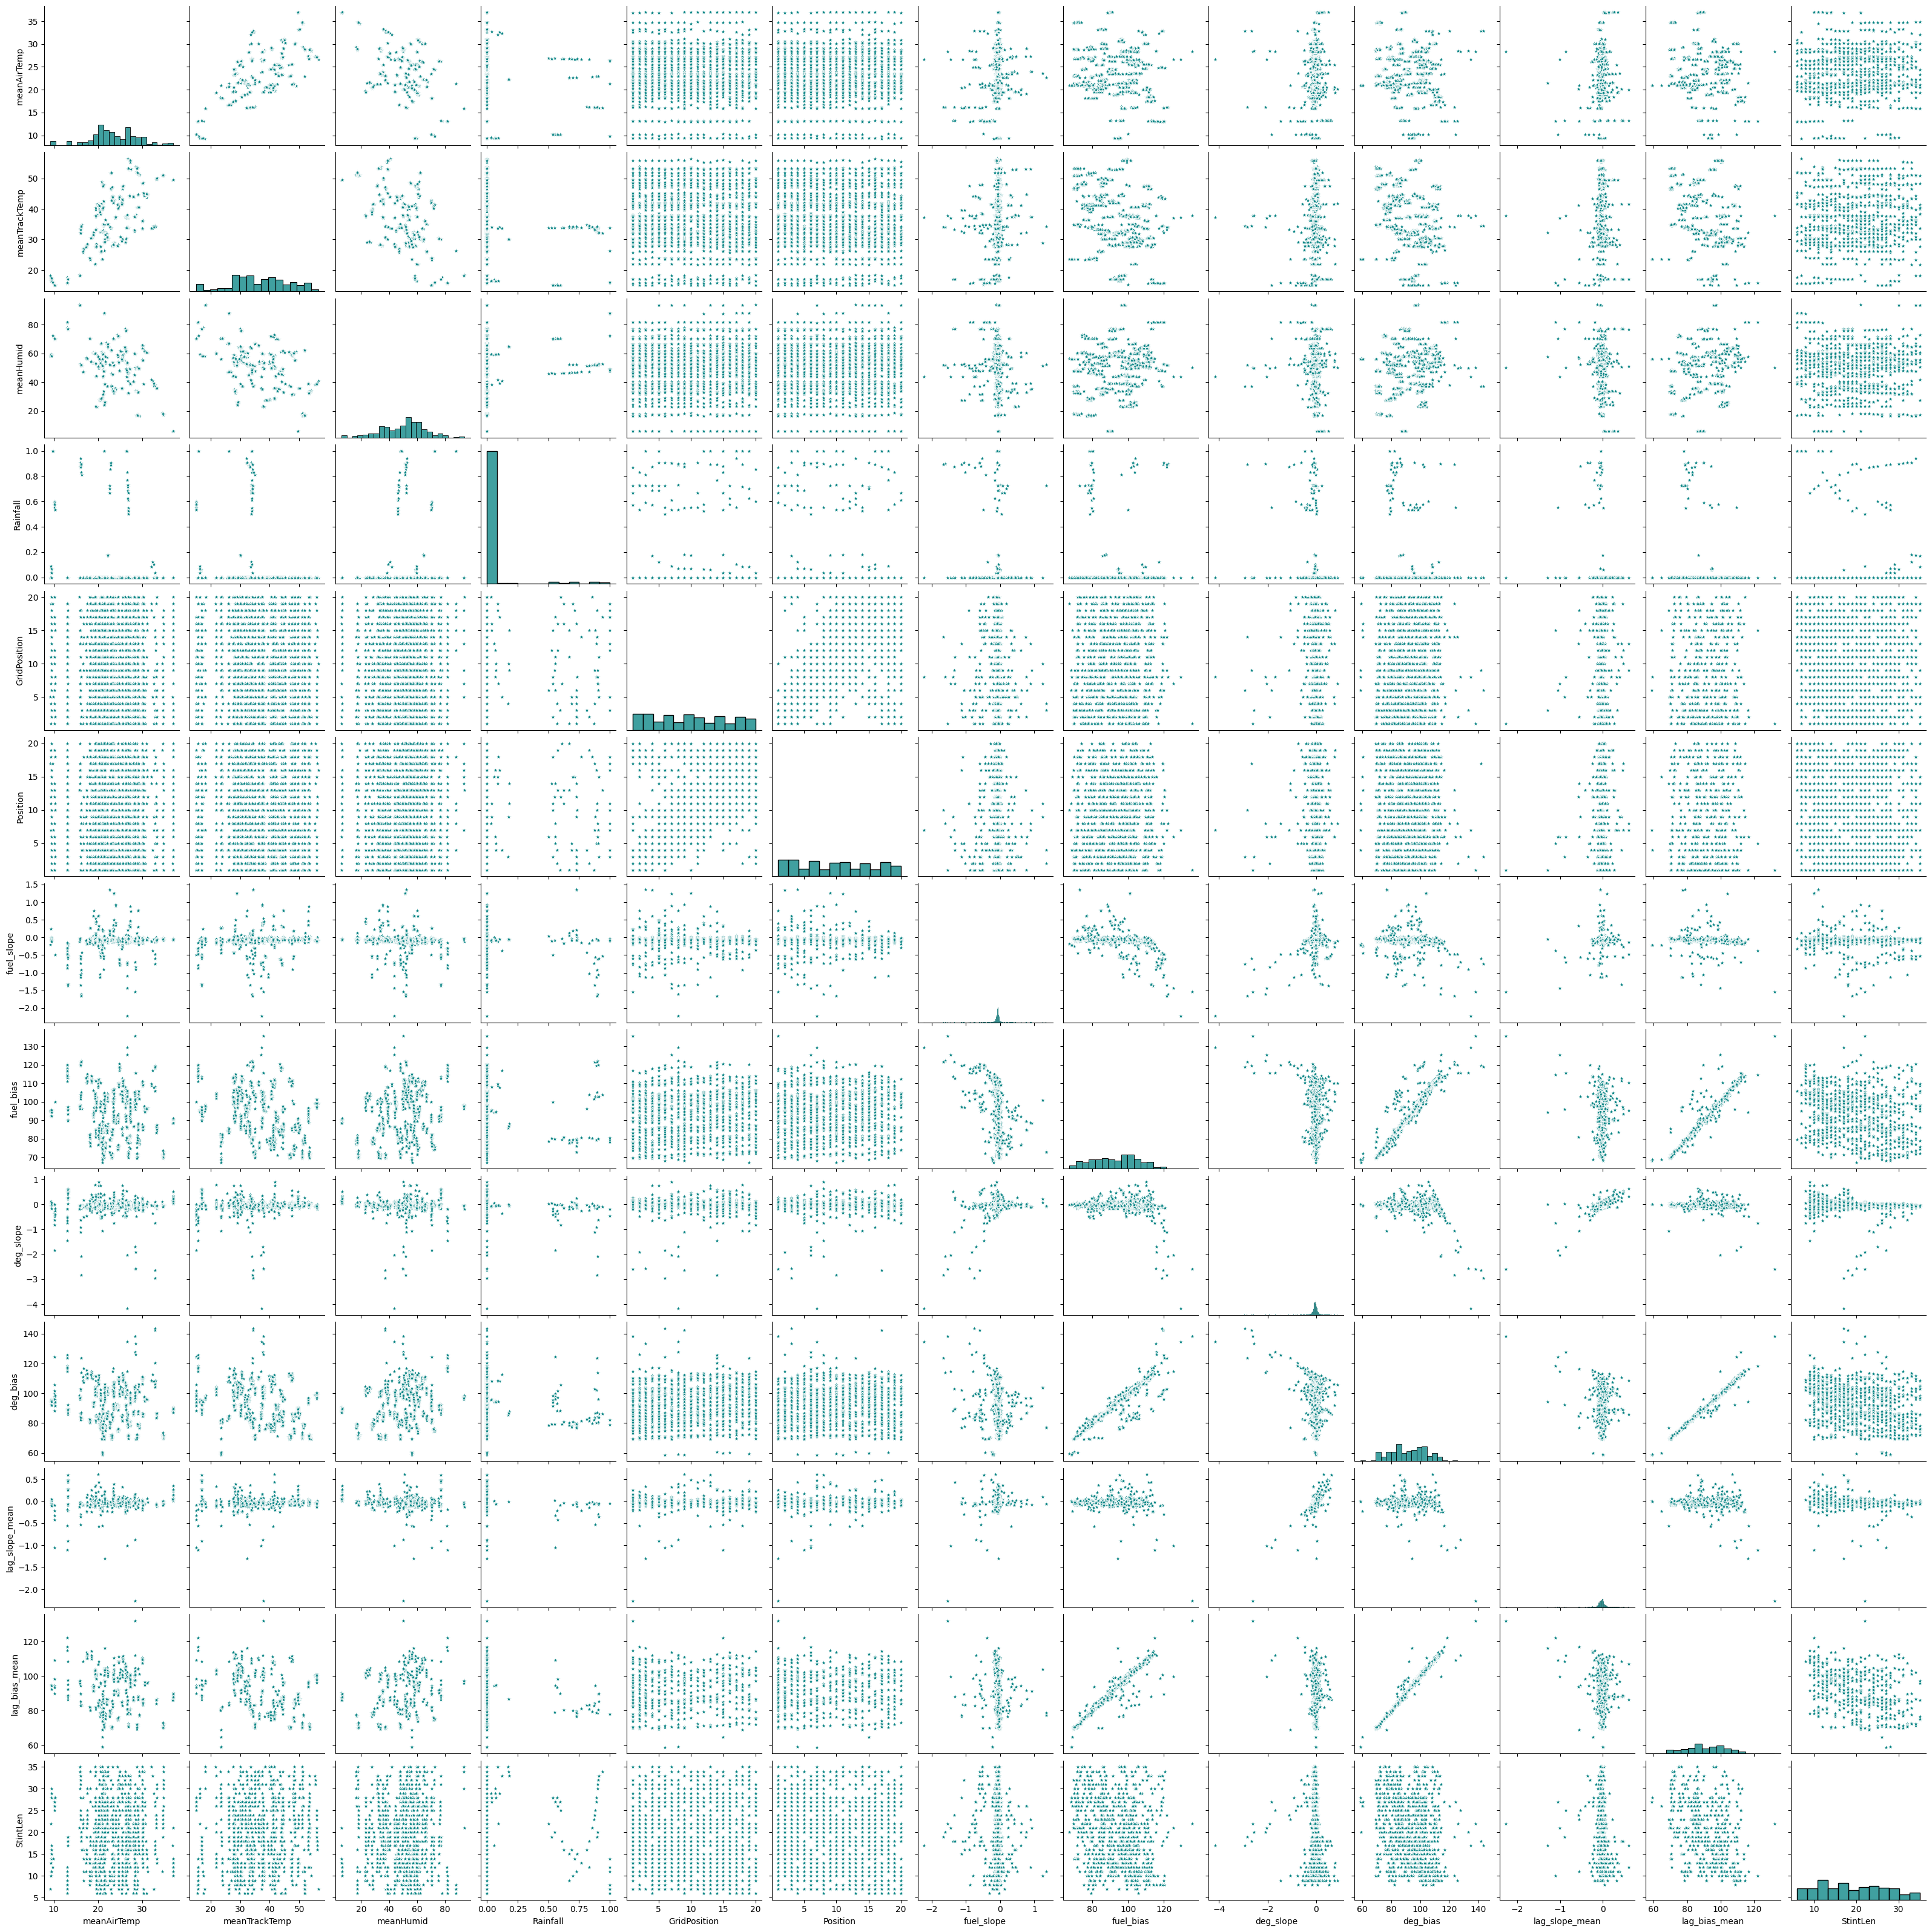

In [10]:
# Display variable correlations

columns = [
    #'Compound', 
    'meanAirTemp', 'meanTrackTemp', 'meanHumid', 'Rainfall',
    'GridPosition', 'Position',
    #'classLabels',
    'fuel_slope','fuel_bias','deg_slope','deg_bias',
    'lag_slope_mean','lag_bias_mean',
    'StintLen'
]

x = df[columns].reset_index(drop=True)

print('*** x  '+'*' * 100,"\n")
display(x[columns].corr())

# definir colunas numéricas
num_cols = x.select_dtypes(include=['int64', 'float64']).columns

sns.pairplot(x[num_cols], markers='*')
plt.show()


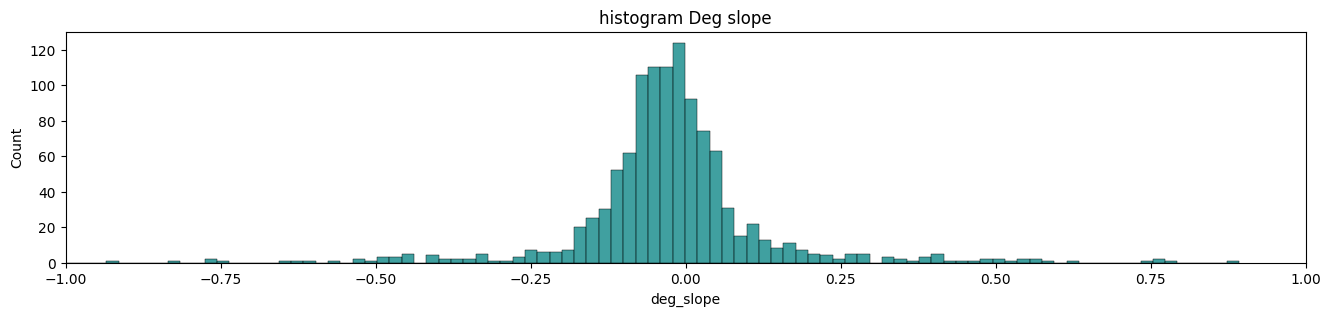

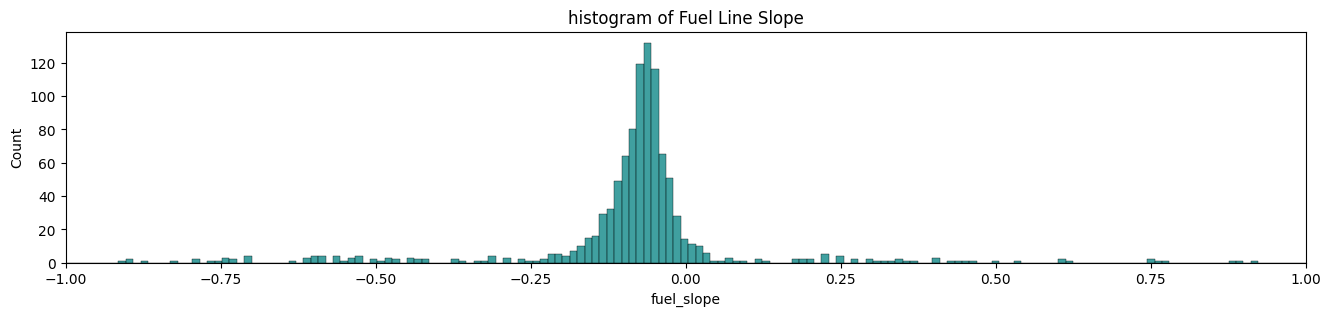

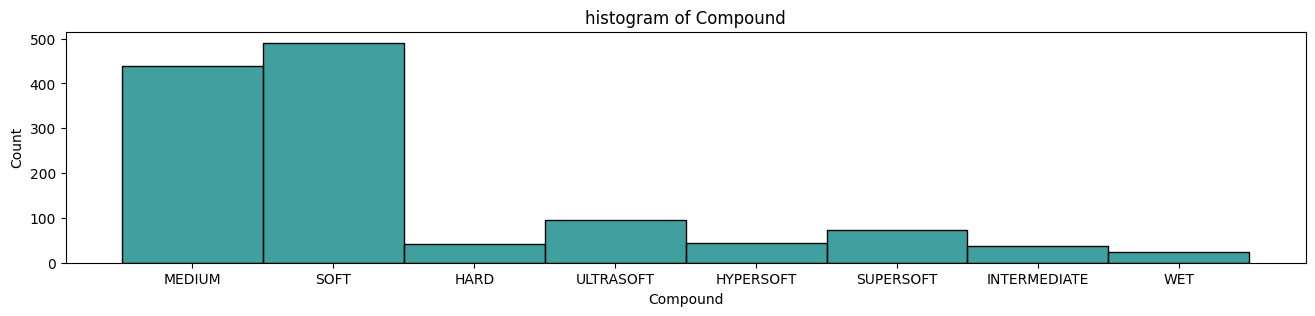

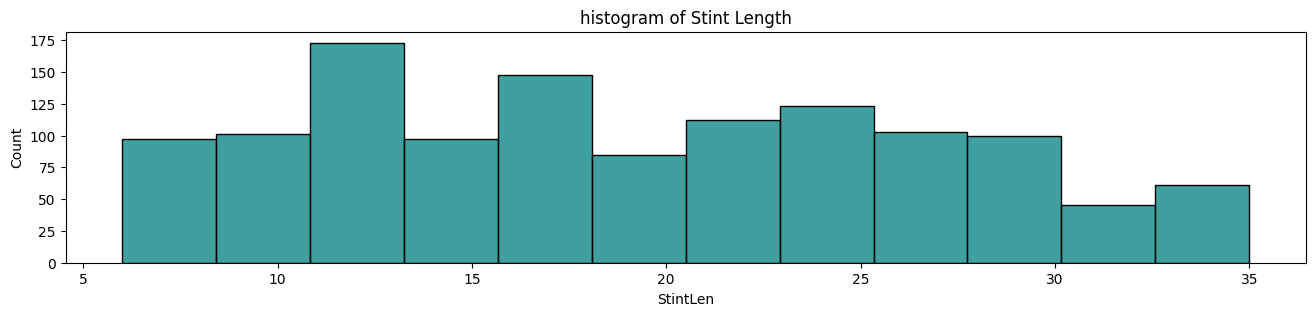

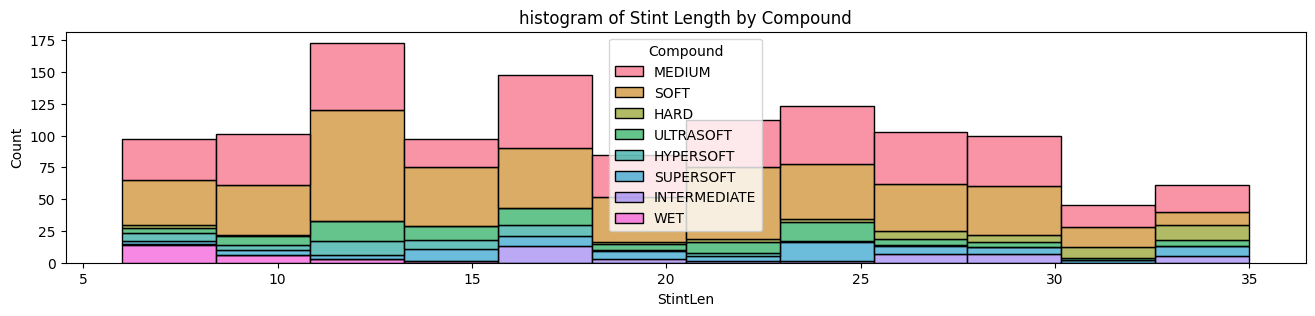

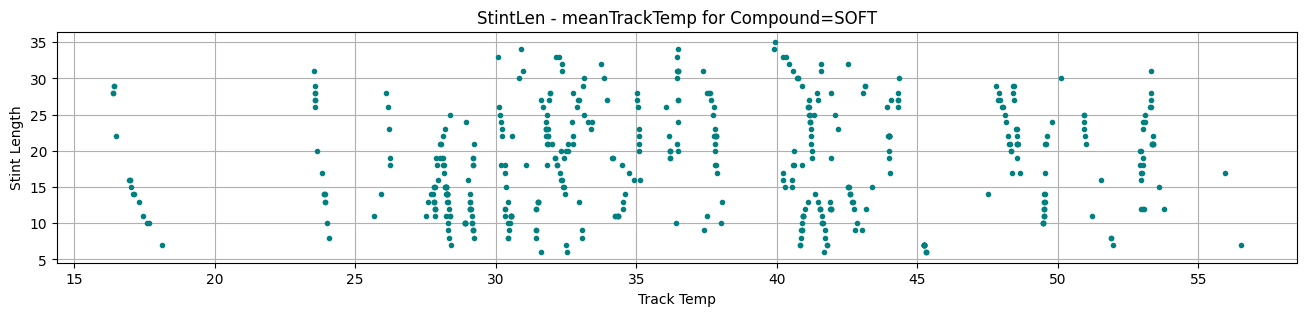

In [11]:
plt.figure(figsize=(16,3))
sns.histplot(data=df, x="deg_slope", multiple="stack")
plt.title('histogram Deg slope')
plt.xlim([-1,1])


plt.figure(figsize=(16,3))
sns.histplot(data=df, x="fuel_slope", multiple="stack")
plt.title('histogram of Fuel Line Slope')
plt.xlim([-1,1])


plt.figure(figsize=(16,3))
sns.histplot(data=df, x="Compound", multiple="stack")
plt.title('histogram of Compound')


plt.figure(figsize=(16,3))
sns.histplot(data=df, x="StintLen")
plt.title('histogram of Stint Length')


plt.figure(figsize=(16,3))
sns.histplot(data=df, x="StintLen", hue="Compound", multiple="stack")
plt.title('histogram of Stint Length by Compound')


plt.figure(figsize=(16,3))
plt.plot(df['meanTrackTemp'][df['Compound']=='SOFT'],df['StintLen'][df['Compound']=='SOFT'],'.')
plt.grid()
plt.title('StintLen - meanTrackTemp for Compound=SOFT')
plt.xlabel('Track Temp')
plt.ylabel('Stint Length')


plt.show()

In [12]:
df.columns

Index(['COLNAME_COL1_MISSING', 'EventName', 'RoundNumber', 'eventYear', 'Team',
       'Compound', 'Driver', 'Stint', 'bestPreRaceTime', 'bestLapTimeIsFrom',
       'meanAirTemp', 'meanTrackTemp', 'meanHumid', 'Rainfall', 'GridPosition',
       'Position', 'raceStintsNums', 'TyreAge', 'lapNumberAtBeginingOfStint',
       'StintLen', 'CircuitLength', 'designedLaps', 'fuel_slope', 'fuel_bias',
       'deg_slope', 'deg_bias', 'lag_slope_mean', 'lag_bias_mean',
       'classLabels'],
      dtype='object')

<a id='modeling'></a>
# Modeling

In [13]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb

from sklearn.model_selection import cross_val_score,StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV

<a id='dataprep'></a>
## Data preparation for modeling

In [14]:
%%time
## prepare data for regression and classification 
sc  = StandardScaler()
le = LabelEncoder()

x = df[['EventName','Compound','Driver','raceStintsNums','TyreAge',
           'meanAirTemp', 'meanTrackTemp', 'meanHumid', 'Rainfall', 
           'GridPosition', 'Position','CircuitLength','classLabels','StintLen']].reset_index(drop=True)


x['EventName'] = le.fit_transform(x['EventName'])
x['Compound'] = le.fit_transform(x['Compound'])
x['Driver'] = le.fit_transform(x['Driver'])


y_mc = x['classLabels']
x_mc = x.drop(['classLabels','StintLen','raceStintsNums'],axis=1) 

## reg based modeling
x_reg = x
y_reg = x_reg['StintLen']
x_reg = x_reg.drop(['classLabels','StintLen', 'raceStintsNums'], axis=1)

CPU times: user 3.83 ms, sys: 0 ns, total: 3.83 ms
Wall time: 3.49 ms


<a id='createtraintestsamples'></a>
## Create train/test samples

In this section, you will preprocess the data. The categorical variables are encoded and missing values are imputed. These steps will be performed with a pipeline and the pipeline is used to transform the independent variables.

In [15]:
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(x_mc, y_mc, test_size=0.25, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.25, random_state=42)
print('Regression data size for train and test: ', len(X_train_reg), len(X_test_reg),'\nClassification data size for train and test: ', len(X_train_mc), len(y_test_mc))

Regression data size for train and test:  933 312 
Classification data size for train and test:  933 312


<a id='regressionforStintOne'></a>
## Regression based model: Only Stint 1


In [16]:
## checking lgbm -- oridinal regression use MAE for performance [one lap from true StintLen]

In [17]:
%%time
gbm = lgbm.LGBMRegressor(
    max_depth=5,
#     num_leaves= 10, learning_rate=  0.01,  n_estimators= 500
)


gbm.fit(X_train_reg, y_train_reg,
#         eval_set=[(X_test_reg, y_test_reg)], eval_metric='l1', callbacks=[lgbm.early_stopping(5)]
)


print('Starting predicting...\n')
# predict
y_pred = gbm.predict(X_test_reg, num_iteration=gbm.best_iteration_)
x_pred = gbm.predict(X_train_reg, num_iteration=gbm.best_iteration_)
mae_test = mean_absolute_error(y_test_reg, y_pred) 
mae_train = mean_absolute_error(y_train_reg, x_pred)
print(f'The MAE of test prediction is: {mae_test}')
print(f'The MAE of train prediction is: {mae_train}')

Starting predicting...

The MAE of test prediction is: 3.510789671381217
The MAE of train prediction is: 2.4276183034372836
CPU times: user 60.9 ms, sys: 1.03 ms, total: 61.9 ms
Wall time: 48.4 ms


## Feature Importances

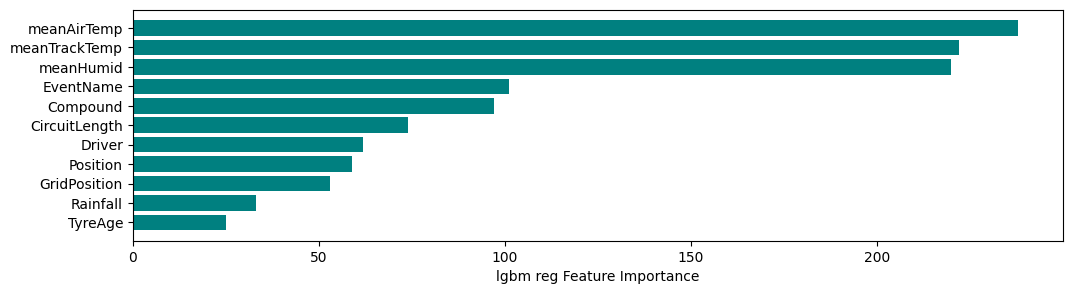

In [18]:
# The closer the feature importance is to 0, the less significance it has to the model.
gbm.feature_importances_
sorted_idx = gbm.feature_importances_.argsort()
sortedFeaNames = [gbm.feature_name_[x] for x in sorted_idx]
fig = plt.figure(figsize=(12,3))
plt.barh(sortedFeaNames, gbm.feature_importances_[sorted_idx])
plt.xlabel("lgbm reg Feature Importance")
plt.show()

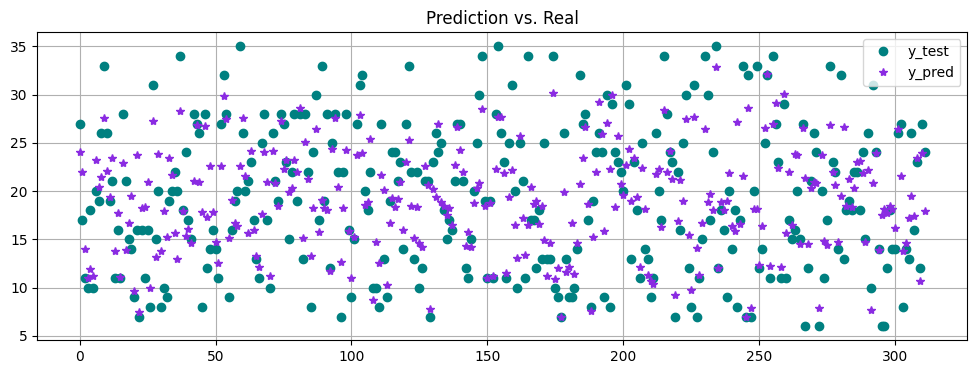

In [19]:
## Prediction vs Real plot

plt.figure(figsize=(12,4) )
plt.plot(range(len(y_pred)),y_test_reg,'o')
plt.plot(range(len(y_pred)),y_pred,'*')
plt.legend(['y_test','y_pred'])
plt.grid()
plt.title('Prediction vs. Real')

plt.show()

## How do Residuals Look Like?
Cumulative of density [#Laps, Cumulative-error] provides total error up to a lap.
For example, 80% of predicted errors are in the range of +-5  laps

Let's have a look at how far off predictions are. This is what test residuals will show.

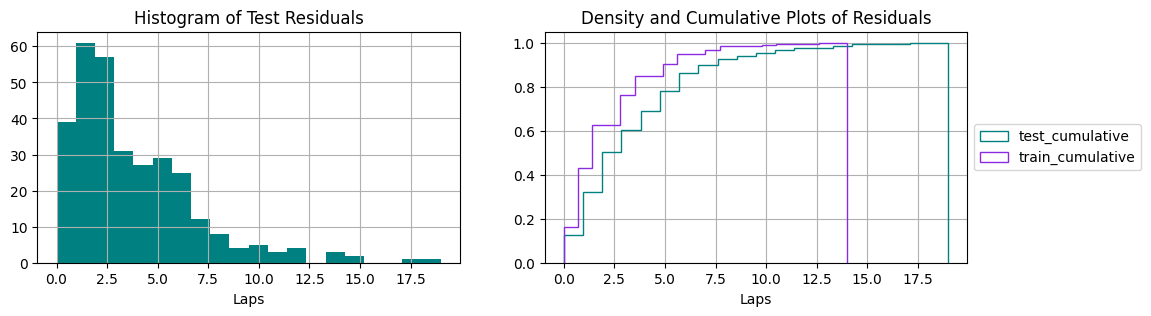

In [20]:
## round y_pred to a closest int number: We want to calculate modeling error in Laps
resid_test = np.abs(np.round(y_pred) - y_test_reg)
resid_train = np.abs(np.round(x_pred) - y_train_reg)
nbins = 20
fig, axs = plt.subplots(1, 2, figsize=(12,3))
axs[0].hist(resid_test,bins=nbins)
axs[0].title.set_text('Histogram of Test Residuals')
axs[0].set_xlabel('Laps')
axs[0].grid()

# axs[1].hist(resid_test, density=True, histtype='step',bins =nbins)
axs[1].hist(resid_test, density=True, cumulative=True, histtype='step',bins =nbins)
# axs[1].hist(resid_train, density=True, histtype='step',bins =nbins)
axs[1].hist(resid_train, density=True, cumulative=True, histtype='step',bins =nbins)
axs[1].legend(['test_cumulative','train_cumulative',],
             loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
axs[1].title.set_text('Density and Cumulative Plots of Residuals')
axs[1].set_xlabel('Laps')
plt.show()

<a id='multiclassmodeling'></a>
## Multiclass Modeling

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import get_scorer
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support as score

In [22]:
%%time
model_accuracy = pd.DataFrame()
model_rocs = pd.DataFrame(columns=['Model'])

models = {
  "LGBM" : LGBMClassifier(max_depth=3,
                          n_estimators=100,
                          learning_rate=0.01),
  'XGB' : XGBClassifier(max_depth=3,
                        n_estimators=100,
                        learning_rate= 0.01)
}

for test, clf in models.items():
    clf.fit(X_train_mc, y_train_mc)
    y_pred = clf.predict(X_test_mc)
    acc = accuracy_score(y_test_mc,y_pred)
    train_acc = accuracy_score(y_train_mc, clf.predict(X_train_mc))

    print("\n", test + ' scores')
    print(acc)
    print(classification_report(y_test_mc,y_pred))
    print(confusion_matrix(y_test_mc,y_pred))

    precision, recall, fscore, support = score(y_test_mc, y_pred)

    # ⬇⬇⬇ substituição do append
    new_row = pd.DataFrame([{
        'Model': test,
        'Test_Accuracy': acc,
        'Train_acc': train_acc,
        'precision': precision,
        'recall': recall,
        'fscore': fscore,
    }])

    model_accuracy = pd.concat([model_accuracy, new_row], ignore_index=True)
    # ⬆⬆⬆ substituição do append

    print('-' * 100,"\n")

res1 = pd.melt(model_accuracy, id_vars=['Model','Test_Accuracy','Train_acc'],
               value_vars=['precision', 'recall', 'fscore'])

cols = ['class_'+str(x) for x in clf.classes_]

res = pd.concat([res1,
                 pd.DataFrame(res1['value'].tolist(), columns=cols)],
                 axis=1).drop('value', axis=1).sort_values(['Model','variable'])

res



 LGBM scores
0.40705128205128205
              precision    recall  f1-score   support

           0       0.49      0.39      0.43        44
           1       0.42      0.60      0.49        65
           2       0.32      0.37      0.34        65
           3       0.39      0.42      0.41        59
           4       0.41      0.24      0.30        51
           5       0.62      0.36      0.45        28

    accuracy                           0.41       312
   macro avg       0.44      0.40      0.40       312
weighted avg       0.42      0.41      0.40       312

[[17 12  9  4  2  0]
 [ 7 39 11  2  6  0]
 [ 2 16 24 17  6  0]
 [ 3 16 13 25  2  0]
 [ 3  8 11 11 12  6]
 [ 3  2  7  5  1 10]]
---------------------------------------------------------------------------------------------------- 


 XGB scores
0.41346153846153844
              precision    recall  f1-score   support

           0       0.47      0.39      0.42        44
           1       0.44      0.54      0.49        

,Model,Test_Accuracy,Train_acc,variable,class_0,class_1,class_2,class_3,class_4,class_5
4,LGBM,0.407051,0.536977,fscore,0.430380,0.493671,0.342857,0.406504,0.300000,0.454545
0,LGBM,0.407051,0.536977,precision,0.485714,0.419355,0.320000,0.390625,0.413793,0.625000
2,LGBM,0.407051,0.536977,recall,0.386364,0.600000,0.369231,0.423729,0.235294,0.357143
5,XGB,0.413462,0.543408,fscore,0.425000,0.486111,0.356589,0.459259,0.314607,0.382979
1,XGB,0.413462,0.543408,precision,0.472222,0.443038,0.359375,0.407895,0.368421,0.473684
3,XGB,0.413462,0.543408,recall,0.386364,0.538462,0.353846,0.525424,0.274510,0.321429


In [23]:
# Print models to check hyperparameters
models

{'LGBM': LGBMClassifier(learning_rate=0.01, max_depth=3),
 'XGB': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.01, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               n_estimators=100, n_jobs=None, num_parallel_tree=None,
               objective='multi:softprob', predictor=None, ...)}

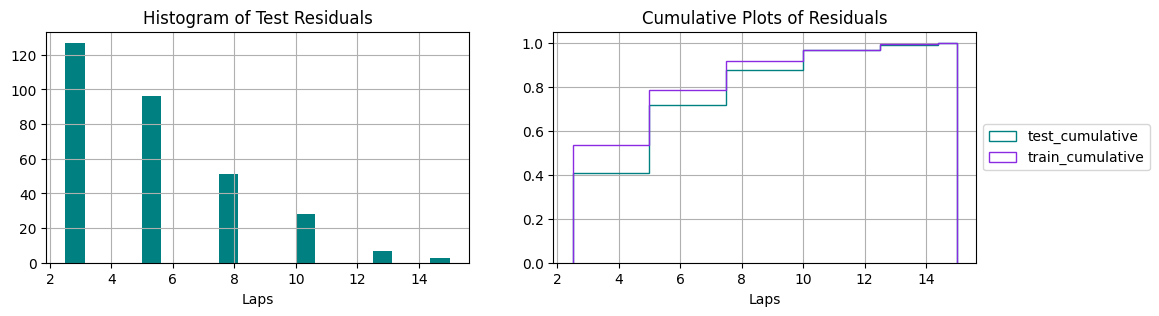

In [24]:
### multiclass model errors
x_pred = models['LGBM'].predict(X_train_mc)
y_pred = models['LGBM'].predict(X_test_mc)

resid_test_mc = (np.abs(y_pred- y_test_mc.astype('category').cat.codes)+1) *2.5
resid_train_mc = (np.abs(x_pred- y_train_mc.astype('category').cat.codes)+1)*2.5
nbins = 20
fig, axs = plt.subplots(1, 2, figsize=(12,3))
axs[0].hist(resid_test_mc,bins=nbins)
axs[0].title.set_text('Histogram of Test Residuals')
axs[0].set_xlabel('Laps')
axs[0].grid()

axs[1].hist(resid_test_mc, density=True, cumulative=True, histtype='step',bins =nbins)
axs[1].hist(resid_train_mc, density=True, cumulative=True, histtype='step',bins =nbins)
axs[1].legend(['test_cumulative','train_cumulative',],
             loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
axs[1].title.set_text('Cumulative Plots of Residuals')
axs[1].set_xlabel('Laps')
plt.show()

<a id='create_pipeline'></a>
## Create Pileline Model and Fit LGBMC (Light Gradient Boosted Model)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from mlxtend.plotting import plot_confusion_matrix

In [26]:
df.columns

Index(['COLNAME_COL1_MISSING', 'EventName', 'RoundNumber', 'eventYear', 'Team',
       'Compound', 'Driver', 'Stint', 'bestPreRaceTime', 'bestLapTimeIsFrom',
       'meanAirTemp', 'meanTrackTemp', 'meanHumid', 'Rainfall', 'GridPosition',
       'Position', 'raceStintsNums', 'TyreAge', 'lapNumberAtBeginingOfStint',
       'StintLen', 'CircuitLength', 'designedLaps', 'fuel_slope', 'fuel_bias',
       'deg_slope', 'deg_bias', 'lag_slope_mean', 'lag_bias_mean',
       'classLabels'],
      dtype='object')

In [27]:
x = df[['EventName','Compound','Driver', 'TyreAge', 
           'meanAirTemp', 'meanTrackTemp', 'meanHumid', 'Rainfall', 
           'GridPosition', 'Position','CircuitLength','designedLaps','classLabels'] ].reset_index(drop=True)

categorical_cols = []
numerical_cols = []

y = x.classLabels
x = x.drop(['classLabels'],axis=1)

X_train_xgbc, X_test_xgbc, y_train_xgbc, y_test_xgbc = train_test_split(
    x, y, test_size=0.25, random_state=42)

print('Regression data size for train and test: ', len(X_train_xgbc), len(X_test_xgbc),
      '\nClassification data size for train and test: ', len(X_train_xgbc), len(y_test_xgbc))

## Extract numerical columns and categorical columns
for col_name, col in X_train_xgbc.items():    # <-- AQUI É A CORREÇÃO
    if col.dtypes == "object":
        categorical_cols.append(col_name)
    else:
        numerical_cols.append(col_name)

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ]
)


## StandardScaler is not needed for tree based models
numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

# Build a pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ("num", numeric_transformer, numerical_cols),
    ])

xgb_classifier = LGBMClassifier(
    max_depth=5,
    n_estimators=50
)

ppl_model = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', xgb_classifier)
    ])

ppl_model.fit(X_train_xgbc, y_train_xgbc)


Regression data size for train and test:  933 312 
Classification data size for train and test:  933 312


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['EventName', 'Compound',
                                                   'Driver']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['TyreAge', 'meanAirTemp',
                                                   'meanTrackTemp', 'meanHumid',
                                                   'Rainfall', 'GridPosition',
                                                   'Position', 'CircuitLength',
                                                   'designedLaps'])])),
                ('model', LGBMClassifier(max_depth=5, n_estimators=50))])

In [28]:
ppl_model.predict(X_test_xgbc[:3])


array([4, 0, 1])

Once the best model has been determined, you use the `.predict()` method to make predictions on a subset of the test dataset. It accepts predictors, in the form of a `DataFrame` object, and returns predicted values.

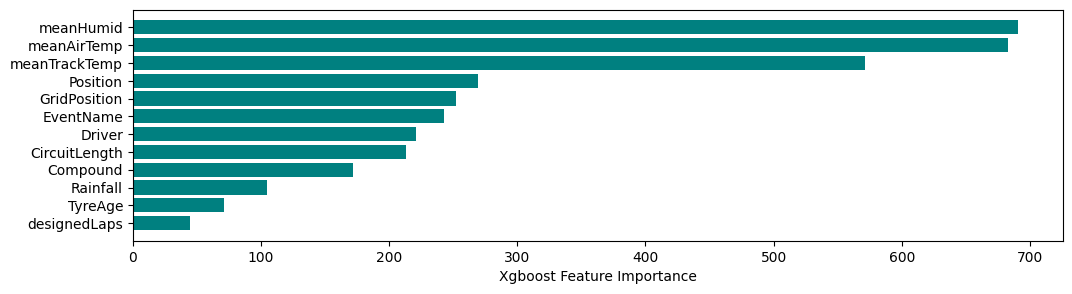

In [29]:
# Print Feature Importances again
sorted_idx = xgb_classifier.feature_importances_.argsort()
fig = plt.figure(figsize=(12,3))
plt.barh(ppl_model.feature_names_in_[sorted_idx], xgb_classifier.feature_importances_[sorted_idx])
plt.xlabel("Xgboost Feature Importance")
plt.show()

In [30]:
def evaluator(y_test, y_pred):    
    # Accuracy:
    print('Accuracy is: ', accuracy_score(y_test,y_pred))
    print('')

    print('Confusion Matrix: \n\n')
    plt.style.use("ggplot")
    cm = confusion_matrix(y_test,y_pred)
    plot_confusion_matrix(conf_mat = cm,figsize=(6,4),show_normed=True)
    plt.show()

In [31]:
# Bins and Labels
print('Bins:', bins)
print('Class Names:', labels)

Bins: [ 5 10 15 20 25 30 35]
Class Names: [0 1 2 3 4 5]


In [32]:
y_pred_prob = ppl_model.predict_proba(X_test_xgbc)
y_pred_bin = ppl_model.predict(X_test_xgbc)
print('Actual: ', list(y_test_xgbc[0:1]) )
print('predicted: ', y_pred_bin[0:1])
print('prediction prob: ', y_pred_prob[0:1])

Actual:  [4]
predicted:  [4]
prediction prob:  [[0.01082821 0.06056211 0.15762455 0.11470082 0.64746024 0.00882407]]


---------------------------------------------------------------------------------------------------- 
Test Accuracy
Accuracy is:  0.5705128205128205

Confusion Matrix: 




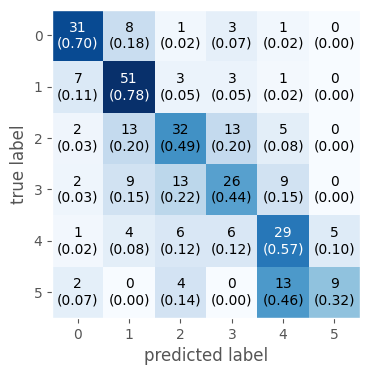

In [33]:
print('-'*100,"\nTest Accuracy")
evaluator(y_test_xgbc, y_pred_bin)

###  Save PipeLine model

In [34]:
import joblib
joblib.dump(ppl_model, "trained_pipeline.joblib")

['trained_pipeline.joblib']

In [35]:
import ads
from ads.model.generic_model import GenericModel
ads.set_auth("resource_principal")

ads_model = GenericModel(
    artifact_dir="model_artifacts",
    estimator=ppl_model
)

ads_model.prepare(
    inference_conda_env="automlx242_p38_cpu_x86_64_v1"
)

model_id = ads_model.save(
    display_name="stint-length-pipeline",
    description="Sklearn pipeline with preprocessing + LightGBM"
)

print("Model registered with OCID:", model_id)


  warnings.warn("slug will be deprecated. Provide conda pack path instead.")

Start loading model.pkl from model directory /home/datascience/fast-track-ml/notebooks/model_artifacts ...
Model is successfully loaded.
['runtime.yaml', '.model-ignore', 'model.pkl', 'score.py']


loop1:   0%|          | 0/4 [00:00<?, ?it/s]

Model registered with OCID: ocid1.datasciencemodel.oc1.sa-saopaulo-1.amaaaaaafioir7iaftvvoqzdcsqaipwpx6k4ihmzky5xjlskyfyjtjchlwkq


In [71]:
import ads
from ads.model.deployment import ModelDeployment

ads.set_auth("resource_principal")

COMPARTMENT_ID = "ocid1.compartment.oc1..aaaaaaaaphu7klxfxmx4rg2oo7yg6sbgbr6qguclbrjqhyxznqqajof4iiyq"
PROJECT_ID = "ocid1.datascienceproject.oc1.sa-saopaulo-1.amaaaaaafioir7iabydani5v2wkq7k5p3qrjkfuy6mmobh5ejyvyqd3mhzla"

deployment = ModelDeployment(
    display_name="stint-length-deployment",
    model_id=model_id,              # OCID do modelo no Model Catalog
    compartment_id=COMPARTMENT_ID,  
    project_id=PROJECT_ID,          
    instance_shape="VM.Standard.E4.Flex",
    instance_count=1,
    ocpus=1,
    memory_in_gbs=8
)

deployment.deploy()


Model Deployment OCID: ocid1.datasciencemodeldeployment.oc1.sa-saopaulo-1.amaaaaaafioir7ia543seeowgit43cge56svfltzzyksnktatgki6dhmtnmq


Creating model deployment:   0%|          | [00:00<?, ?it/s]


kind: deployment
spec:
  createdBy: ocid1.datasciencenotebooksession.oc1.sa-saopaulo-1.amaaaaaafioir7iar3vyetdknsdpg5aylwjmrw3c5usnwik5wkpclby7uhqa
  definedTags:
    0-ResourceControl:
      CreatedAt: '2025-12-14T21:22:12.501Z'
      CreatedBy: ocid1.datasciencenotebooksession.oc1.sa-saopaulo-1.amaaaaaafioir7iar3vyetdknsdpg5aylwjmrw3c5usnwik5wkpclby7uhqa
      DeleteResource: WeeklyDeleteResourceYes
      KeepResource: Enter the reason to keep it
      ShutdownResource: NightlyShutdownYes
      ShutdownTime: Enter the reason to keep it
      Team: To_be_Assigned
  displayName: stint-length-deployment
  id: ocid1.datasciencemodeldeployment.oc1.sa-saopaulo-1.amaaaaaafioir7ia543seeowgit43cge56svfltzzyksnktatgki6dhmtnmq
  infrastructure:
    kind: infrastructure
    spec:
      bandwidthMbps: 10
      compartmentId: ocid1.compartment.oc1..aaaaaaaaphu7klxfxmx4rg2oo7yg6sbgbr6qguclbrjqhyxznqqajof4iiyq
      deploymentType: SINGLE_MODEL
      policyType: FIXED_SIZE
      projectId: ocid1.da

In [36]:
import oci
import requests
import json

# =====================================================
# 1. DEPLOYMENT OCID 
# =====================================================
DEPLOYMENT_ID = "ocid1.datasciencemodeldeployment.oc1.sa-saopaulo-1.amaaaaaafioir7ia543seeowgit43cge56svfltzzyksnktatgki6dhmtnmq"

# =====================================================
# 2. Resource Principal signer
# =====================================================
signer = oci.auth.signers.get_resource_principals_signer()

# =====================================================
# 3. Data Science client
# =====================================================
ds_client = oci.data_science.DataScienceClient(
    config={},
    signer=signer
)

# =====================================================
# 4. Obter endpoint
# =====================================================
deployment = ds_client.get_model_deployment(DEPLOYMENT_ID).data
endpoint = deployment.model_deployment_url

if not endpoint.endswith("/predict"):
    endpoint = endpoint.rstrip("/") + "/predict"

print("Endpoint:", endpoint)

# =====================================================
# 5. Payload 
# =====================================================
payload = {
    "EventName": ["Monaco GP"],
    "Compound": ["SOFT"],
    "Driver": ["VER"],
    "TyreAge": [5],
    "meanAirTemp": [22.0],
    "meanTrackTemp": [38.0],
    "meanHumid": [60.0],
    "Rainfall": [0.0],
    "GridPosition": [1],
    "Position": [1],
    "CircuitLength": [3.337],
    "designedLaps": [78]
}


# =====================================================
# 6. Inferência
# =====================================================
response = requests.post(
    endpoint,
    json=payload,
    auth=signer,
    headers={"Content-Type": "application/json"},
    timeout=60
)

print("HTTP status:", response.status_code)

try:
    print("Response JSON:")
    print(json.dumps(response.json(), indent=2))
except Exception:
    print("Response text:")
    print(response.text)


Endpoint: https://modeldeployment.sa-saopaulo-1.oci.customer-oci.com/ocid1.datasciencemodeldeployment.oc1.sa-saopaulo-1.amaaaaaafioir7ia543seeowgit43cge56svfltzzyksnktatgki6dhmtnmq/predict
HTTP status: 200
Response JSON:
{
  "prediction": [
    1
  ]
}


In [37]:
class_to_range = {
    0: (5,10),
    1: (10,15),
    2: (15,20),
    3: (20,25),
    4: (25,30),
    5: (30,35)
}

pred_class = response.json()["prediction"][0]
print("Classe:", pred_class)
print("Intervalo previsto:", class_to_range[pred_class])


Classe: 1
Intervalo previsto: (10, 15)


## Job

In [38]:
%%writefile job.py
import oci
import requests
import json
from datetime import datetime

# =========================
# CONFIGURAÇÕES
# =========================
DEPLOYMENT_ID = "ocid1.datasciencemodeldeployment.oc1.sa-saopaulo-1.amaaaaaafioir7ia543seeowgit43cge56svfltzzyksnktatgki6dhmtnmq"
BUCKET_NAME = "job-results"   # bucket onde o resultado será salvo

# =========================
# Resource Principal
# =========================
signer = oci.auth.signers.get_resource_principals_signer()

# =========================
# Clients OCI
# =========================
ds_client = oci.data_science.DataScienceClient(
    config={},
    signer=signer
)

os_client = oci.object_storage.ObjectStorageClient(
    config={},
    signer=signer
)

namespace = os_client.get_namespace().data

# =========================
# Obter endpoint do modelo
# =========================
deployment = ds_client.get_model_deployment(DEPLOYMENT_ID).data
endpoint = deployment.model_deployment_url.rstrip("/") + "/predict"

# =========================
# Payload
# =========================
payload = {
    "EventName": ["Monaco GP"],
    "Compound": ["SOFT"],
    "Driver": ["VER"],
    "TyreAge": [5],
    "meanAirTemp": [22.0],
    "meanTrackTemp": [38.0],
    "meanHumid": [60.0],
    "Rainfall": [0.0],
    "GridPosition": [1],
    "Position": [1],
    "CircuitLength": [3.337],
    "designedLaps": [78]
}

# =========================
# Chamada do modelo
# =========================
response = requests.post(
    endpoint,
    json=payload,
    auth=signer,
    headers={"Content-Type": "application/json"},
    timeout=60
)

response.raise_for_status()
result = response.json()

# =========================
# Salvar resultado no Object Storage
# =========================
object_name = f"resultado_job_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}.json"

os_client.put_object(
    namespace_name=namespace,
    bucket_name=BUCKET_NAME,
    object_name=object_name,
    put_object_body=json.dumps({
        "input": payload,
        "output": result
    }, indent=2).encode("utf-8")
)

print("Resultado salvo no Object Storage:")
print(f"Bucket: {BUCKET_NAME}")
print(f"Object: {object_name}")

print("JOB FINALIZADO COM SUCESSO")


Overwriting job.py


## Export Autonomous

In [39]:
# ============================
#  EXPORTAÇÃO - REGRESSÃO LGBM
# ============================

# Garantir que y_pred existe (última predição LGBM)
y_pred_reg = gbm.predict(X_test_reg)

# Construir DataFrame exportável
df_export_reg = X_test_reg.copy()
df_export_reg = df_export_reg.reset_index(drop=True)

df_export_reg["y_real"] = y_test_reg.reset_index(drop=True)
df_export_reg["y_pred"] = y_pred_reg
df_export_reg["erro"] = abs(df_export_reg["y_real"] - df_export_reg["y_pred"])

df_export_reg.head()


,EventName,Compound,Driver,TyreAge,meanAirTemp,meanTrackTemp,meanHumid,Rainfall,GridPosition,Position,CircuitLength,y_real,y_pred,erro
0,16,4,3,4.0,21.070370,32.933333,51.462963,0.0,3,2,5.793,27,24.001246,2.998754
1,8,6,2,3.0,20.494118,39.429412,27.452941,0.0,14,18,4.361,17,21.962822,4.962822
2,27,4,23,4.0,36.927273,49.500000,6.181818,0.0,9,12,4.655,11,13.954923,2.954923
3,5,3,14,1.0,18.470000,30.540000,54.460000,0.0,19,16,7.004,10,10.975739,0.975739
4,5,4,21,4.0,18.783333,31.077778,53.672222,0.0,8,10,7.004,18,11.933628,6.066372


In [40]:
# ====================================
#  EXPORTAÇÃO - CLASSIFICAÇÃO XGBOOST
# ====================================

# Garantir que predictions existem:
y_pred_xgb = y_pred_bin                     # previsões de classe
y_prob_xgb = y_pred_prob.max(axis=1)        # probabilidade da classe prevista

df_export_clf = X_test_xgbc.copy()
df_export_clf = df_export_clf.reset_index(drop=True)

df_export_clf["y_real"] = y_test_xgbc.reset_index(drop=True)
df_export_clf["y_pred"] = y_pred_xgb
df_export_clf["prob_pred"] = y_prob_xgb

df_export_clf.head()


,EventName,Compound,Driver,TyreAge,meanAirTemp,meanTrackTemp,meanHumid,Rainfall,GridPosition,Position,CircuitLength,designedLaps,y_real,y_pred,prob_pred
0,Italian Grand Prix,SOFT,BOT,4.0,21.070370,32.933333,51.462963,0.0,3,2,5.793,53,4,4,0.647460
1,Canadian Grand Prix,ULTRASOFT,ALO,3.0,20.494118,39.429412,27.452941,0.0,14,18,4.361,70,2,0,0.376479
2,Spanish Grand Prix,SOFT,RIC,4.0,36.927273,49.500000,6.181818,0.0,9,12,4.655,66,1,1,0.748450
3,Belgian Grand Prix,MEDIUM,LAT,1.0,18.470000,30.540000,54.460000,0.0,19,16,7.004,44,0,0,0.817666
4,Belgian Grand Prix,SOFT,PER,4.0,18.783333,31.077778,53.672222,0.0,8,10,7.004,44,2,1,0.734059


In [43]:
# ==========================================
#  CONEXÃO + EXPORTAÇÃO DOS RESULTADOS
# ==========================================

import oracledb

# -------------------------------
# 1) Conexão ao Autonomous (thin)
# -------------------------------
conn = oracledb.connect(
    user=user,
    password=password,
    dsn="(description= (retry_count=20)(retry_delay=3)"
         "(address=(protocol=tcps)(port=1522)(host=adb.sa-saopaulo-1.oraclecloud.com))"
         "(connect_data=(service_name=jy2otyfomimhaoc_dbtest_high.adb.oraclecloud.com))"
         "(security=(ssl_server_dn_match=yes)))",
    config_dir="/home/datascience/fast-track-ml/wallet",
    wallet_location="/home/datascience/fast-track-ml/wallet",
    wallet_password=password
)

cur = conn.cursor()

print("Conexão estabelecida")

# ==========================================
# 2) Exportar LGBM (Regressão)
# ==========================================

print("Exportando resultados do modelo LGBM (Regressão)...")

# Garantir tipos NUMBER
cols_reg = ", ".join([f"{c} NUMBER" for c in df_export_reg.columns])

# Remover tabela se existir
try:
    cur.execute("DROP TABLE resultados_lgbm_reg PURGE")
except:
    pass

# Criar tabela
cur.execute(f"""
    CREATE TABLE resultados_lgbm_reg (
        {cols_reg}
    )
""")

# Inserir dados
placeholders = ",".join([f":{i+1}" for i in range(len(df_export_reg.columns))])
data_reg = [tuple(row) for row in df_export_reg.to_numpy()]

cur.executemany(
    f"INSERT INTO resultados_lgbm_reg VALUES ({placeholders})",
    data_reg
)

conn.commit()
print("Tabela resultados_lgbm_reg criada e carregada com sucesso!")


# ==========================================
# 3) Exportar XGBoost (Classificação)
# ==========================================

print("Exportando resultados do modelo XGBoost (Classificação)...")

# Detectar colunas numéricas vs categóricas
cols_clf = ", ".join([
    f"{c} VARCHAR2(200)" if df_export_clf[c].dtype == "object" else f"{c} NUMBER"
    for c in df_export_clf.columns
])

# Remover tabela se existir
try:
    cur.execute("DROP TABLE resultados_xgboost_clf PURGE")
except:
    pass

# Criar tabela
cur.execute(f"""
    CREATE TABLE resultados_xgboost_clf (
        {cols_clf}
    )
""")

# Inserir dados
placeholders = ",".join([f":{i+1}" for i in range(len(df_export_clf.columns))])
data_clf = [tuple(row) for row in df_export_clf.to_numpy()]

cur.executemany(
    f"INSERT INTO resultados_xgboost_clf VALUES ({placeholders})",
    data_clf
)

conn.commit()
print("Tabela resultados_xgboost_clf criada e carregada com sucesso!")


print("Finalizado!")


Conexão estabelecida
Exportando resultados do modelo LGBM (Regressão)...
Tabela resultados_lgbm_reg criada e carregada com sucesso!
Exportando resultados do modelo XGBoost (Classificação)...
Tabela resultados_xgboost_clf criada e carregada com sucesso!
Finalizado!
